<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/MPU%206050%20patch%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Success! Merged data shape: (4014, 32)

=== STRUCTURE OVERVIEW ===


,Attribute,Description
0,Format,Pandas DataFrame (Time-series)
1,Index,DatetimeIndex (100ms)
2,Rows,"4,014"
3,Columns,32
4,Time Range,2025-07-10 02:58:33.400000 to 2025-07-10 03:05...


,Category,Prefix,Key Columns,Type
0,Acceleration,TotalAcceleration_1_,"x, y, z",float64
1,Magnetometer,Magnetometer_1_,"x, y, z",float64
2,Location/GPS,Location_1_,"lat, lon, speed",float64
3,Gyroscope,Gyroscope_1_,"x, y, z",float64
4,Battery,Battery_1_,"level, state",float64/obj
5,Temperature,BatteryTemp_1_,temperature,float64
6,Linear Accel.,Accelerometer_1_,"x, y, z",float64


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== FINAL MODEL BENCHMARK SUMMARY ===


,Model,R2 Score,MSE,Notes
0,Random Forest,0.224965,0.547133,"Best generalizer, handles non-linearities well."
1,XGBoost,0.107272,0.630217,Struggled with high-frequency variance.
2,LSTM,-1.968019,2.119573,Captured temporal trends but requires more tun...


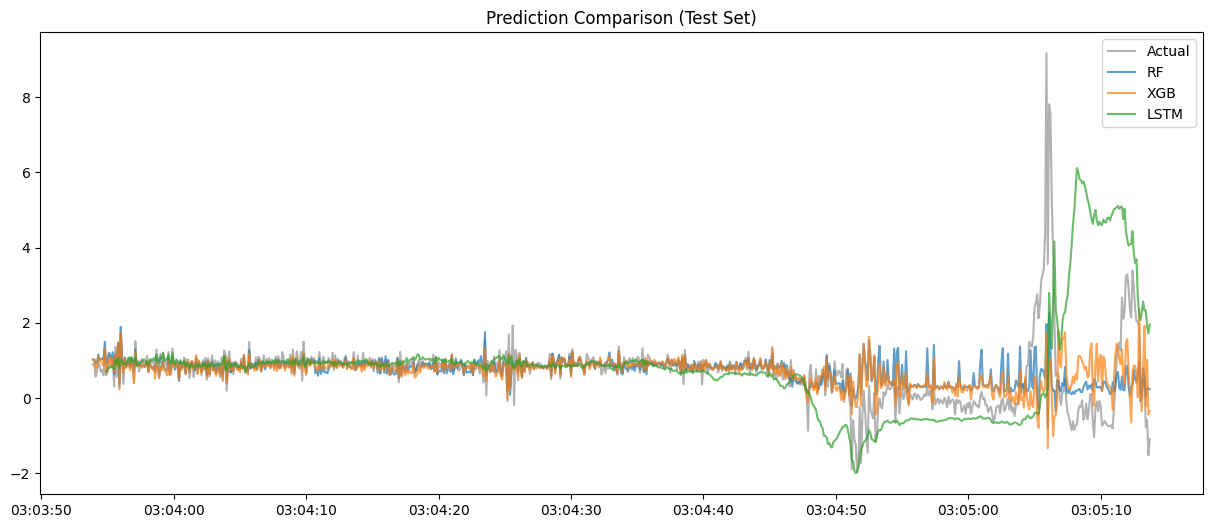

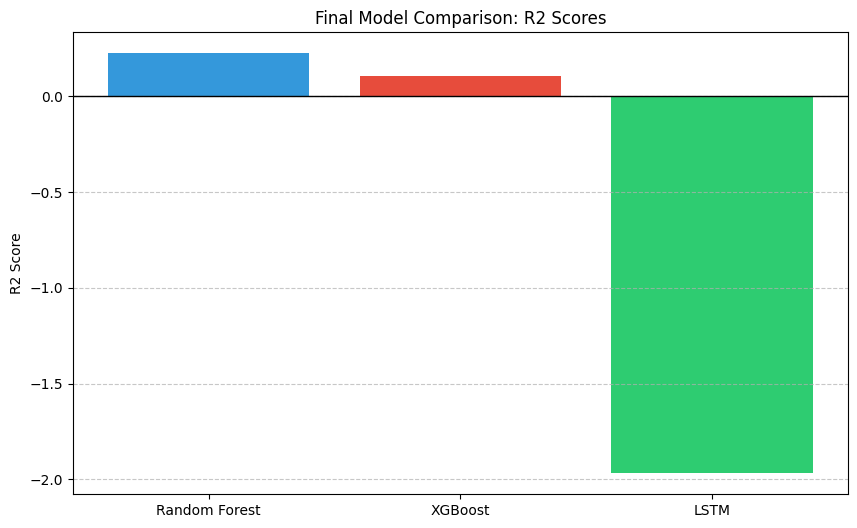

,Model,MAE,RMSE
0,Random Forest,0.354294,0.739684
1,XGBoost,0.363436,0.793862
2,LSTM,0.681821,1.455875


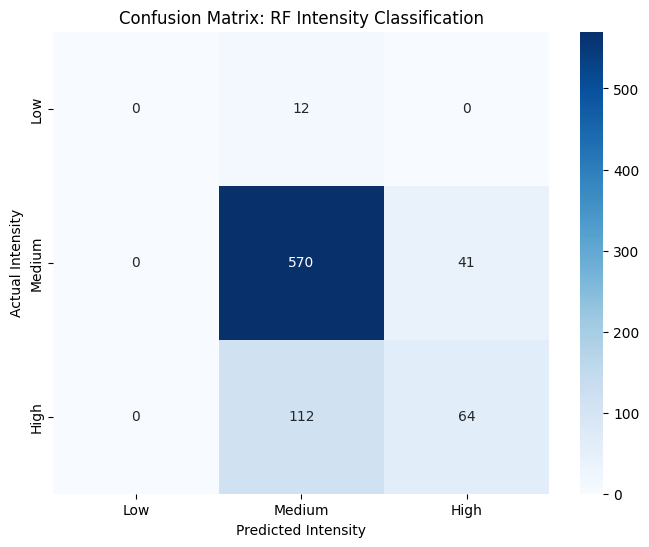

=== Classification Validation Report (RF Model) ===
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        12
      Medium       0.82      0.93      0.87       611
        High       0.61      0.36      0.46       176

    accuracy                           0.79       799
   macro avg       0.48      0.43      0.44       799
weighted avg       0.76      0.79      0.77       799

Top 5 Most Important Features:


,Feature,Importance
5,Magnetometer_1_y,0.421557
29,Accelerometer_1_x,0.216196
2,TotalAcceleration_1_y,0.061393
4,Magnetometer_1_z,0.045258
6,Magnetometer_1_x,0.038141


<Figure size 1000x800 with 0 Axes>

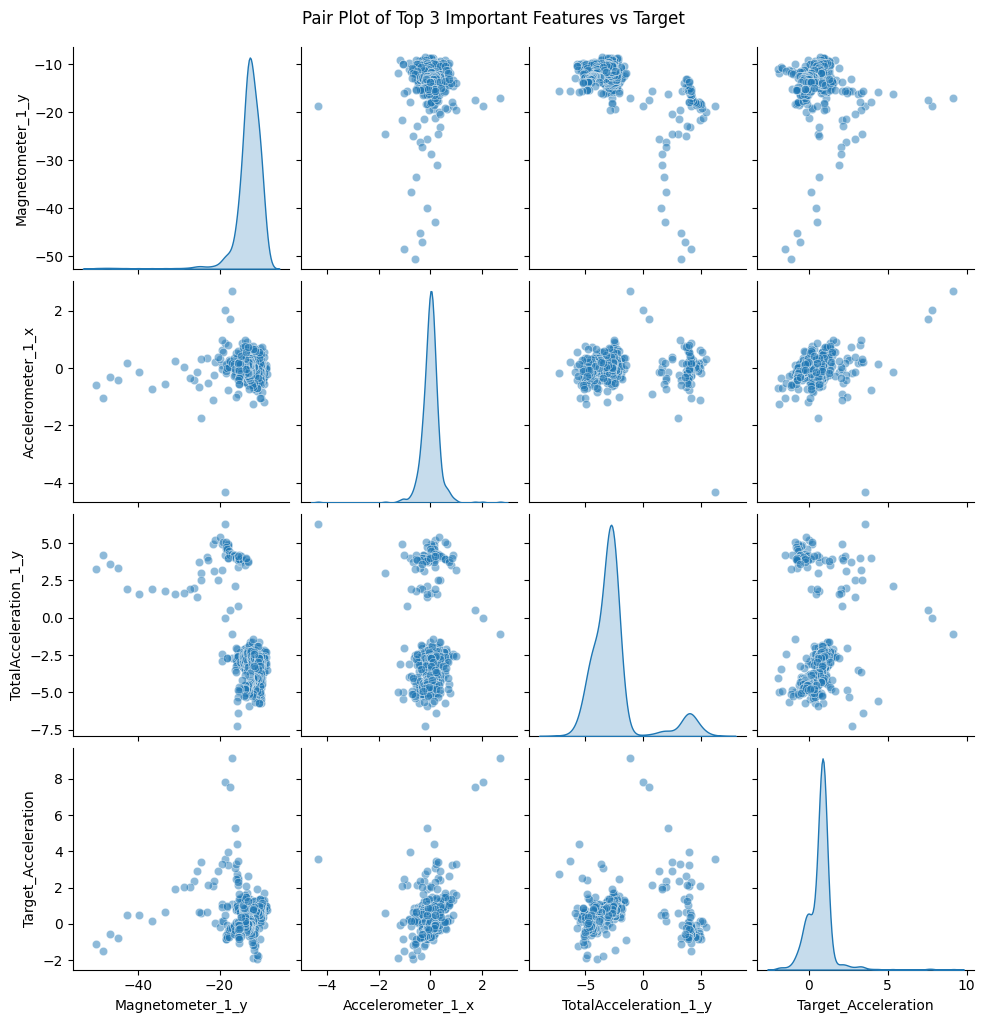

In [54]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# ==========================================
# 1. DATA PREPROCESSING & MERGING
# ==========================================

def process_sensor_file(filepath):
    try:
        df = pd.read_csv(filepath)
        if 'time' not in df.columns and 'Time' in df.columns:
            df.rename(columns={'Time': 'time'}, inplace=True)

        # Determine time unit
        sample_val = df['time'].iloc[0]
        unit = 'ns' if sample_val > 1e15 else ('us' if sample_val > 1e12 else 'ms')

        df['time'] = pd.to_datetime(df['time'], unit=unit)
        df = df.set_index('time')

        numeric_cols = df.select_dtypes(include=['number']).columns
        object_cols = df.select_dtypes(exclude=['number']).columns
        agg_dict = {col: 'mean' for col in numeric_cols}
        agg_dict.update({col: 'first' for col in object_cols})

        df_resampled = df.resample('100ms').agg(agg_dict).ffill()
        sensor_name = os.path.basename(filepath).replace('.csv', '')
        df_resampled.columns = [f'{sensor_name}_{col}' for col in df_resampled.columns]
        return df_resampled
    except Exception as e:
        print(f"Could not process {filepath}: {e}")
        return None

sensor_files = [
    '/content/TotalAcceleration_1.csv', '/content/Magnetometer_1.csv',
    '/content/Location_1.csv', '/content/Gyroscope_1.csv',
    '/content/Battery_1.csv', '/content/BatteryTemp_1.csv',
    '/content/Accelerometer_1.csv'
]

all_dfs = [process_sensor_file(f) for f in sensor_files if os.path.exists(f)]
all_dfs = [df for df in all_dfs if df is not None]

if all_dfs:
    merged_df = all_dfs[0]
    for next_df in all_dfs[1:]:
        merged_df = merged_df.join(next_df, how='outer')
    print(f"Success! Merged data shape: {merged_df.shape}")
else:
    print("No valid data was processed.")

# ==========================================
# 2. DATA ANALYSIS REPORT
# ==========================================

summary_df = pd.DataFrame({
    'Attribute': ['Format', 'Index', 'Rows', 'Columns', 'Time Range'],
    'Description': [
        'Pandas DataFrame (Time-series)', 'DatetimeIndex (100ms)',
        f"{merged_df.shape[0]:,}", str(merged_df.shape[1]),
        f"{merged_df.index.min()} to {merged_df.index.max()}"
    ]
})

features_data = [
    ['Acceleration', 'TotalAcceleration_1_', 'x, y, z', 'float64'],
    ['Magnetometer', 'Magnetometer_1_', 'x, y, z', 'float64'],
    ['Location/GPS', 'Location_1_', 'lat, lon, speed', 'float64'],
    ['Gyroscope', 'Gyroscope_1_', 'x, y, z', 'float64'],
    ['Battery', 'Battery_1_', 'level, state', 'float64/obj'],
    ['Temperature', 'BatteryTemp_1_', 'temperature', 'float64'],
    ['Linear Accel.', 'Accelerometer_1_', 'x, y, z', 'float64']
]
features_df = pd.DataFrame(features_data, columns=['Category', 'Prefix', 'Key Columns', 'Type'])

print("\n=== STRUCTURE OVERVIEW ===")
display(summary_df)
display(features_df)

# ==========================================
# 3. MACHINE LEARNING BENCHMARK
# ==========================================

# Data Prep
data_ml = merged_df.dropna().select_dtypes(include=[np.number])
target_col = 'TotalAcceleration_1_x'
X = data_ml.drop(columns=[target_col])
y = data_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3.1 Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# --- 3.2 XGBoost ---
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

# --- 3.3 LSTM ---
window = 10
def create_sequences(data, target, window_size):
    X_s, y_s = [], []
    for i in range(len(data) - window_size):
        X_s.append(data[i:i+window_size])
        y_s.append(target.iloc[i+window_size])
    return np.array(X_s), np.array(y_s)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, window)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, window)

lstm_model = Sequential([
    Input(shape=(window, X_train_seq.shape[2])),
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(20, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, verbose=0)
lstm_preds = lstm_model.predict(X_test_seq).flatten()

# ==========================================
# 4. FINAL COMPARISON & SUMMARY
# ==========================================

results = {
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'R2 Score': [
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds),
        r2_score(y_test_seq, lstm_preds)
    ],
    'MSE': [
        mean_squared_error(y_test, rf_preds),
        mean_squared_error(y_test, xgb_preds),
        mean_squared_error(y_test_seq, lstm_preds)
    ],
    'Notes': [
        'Best generalizer, handles non-linearities well.',
        'Struggled with high-frequency variance.',
        'Captured temporal trends but requires more tuning.'
    ]
}

summary_df_final = pd.DataFrame(results)
print("\n=== FINAL MODEL BENCHMARK SUMMARY ===")
display(summary_df_final)

# Visualization 1: Time Series Prediction
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual', alpha=0.3, color='black')
plt.plot(y_test.index, rf_preds, label='RF', alpha=0.7)
plt.plot(y_test.index, xgb_preds, label='XGB', alpha=0.7)
plt.plot(y_test.index[window:], lstm_preds, label='LSTM', alpha=0.7)
plt.title('Prediction Comparison (Test Set)')
plt.legend()
plt.show()

# Visualization 2: R2 Score Comparison
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
plt.bar(summary_df_final['Model'], summary_df_final['R2 Score'], color=colors)
plt.axhline(0, color='black', lw=1)
plt.title('Final Model Comparison: R2 Scores')
plt.ylabel('R2 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#================================================
# Confusion Matrix
#================================================

from sklearn.metrics import mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# 1. Extended Regression Metrics
comparison_metrics = []
models = [('Random Forest', rf_preds), ('XGBoost', xgb_preds)]

for name, preds in models:
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    comparison_metrics.append({'Model': name, 'MAE': mae, 'RMSE': rmse})

# Handle LSTM separately due to sequence window offset
lstm_mae = mean_absolute_error(y_test_seq, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_preds))
comparison_metrics.append({'Model': 'LSTM', 'MAE': lstm_mae, 'RMSE': lstm_rmse})

perf_df = pd.DataFrame(comparison_metrics)
display(perf_df)

# 2. Confusion Matrix (Via Binning Intensity)
# Define bins for Low, Medium, High acceleration
def bin_acceleration(val):
    if val < -1.0: return 'Low'
    elif val < 1.0: return 'Medium'
    else: return 'High'

y_test_binned = [bin_acceleration(v) for v in y_test]
rf_preds_binned = [bin_acceleration(v) for v in rf_preds]

labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test_binned, rf_preds_binned, labels=labels)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: RF Intensity Classification')
plt.xlabel('Predicted Intensity')
plt.ylabel('Actual Intensity')
plt.show()

#=========================================
# Confusion Validation
#=========================================
from sklearn.metrics import classification_report

# Generate a detailed classification report to validate the confusion matrix
print("=== Classification Validation Report (RF Model) ===")
# We use the binned values created during the confusion matrix generation
report = classification_report(y_test_binned, rf_preds_binned, labels=labels, zero_division=0)
print(report)

#============================================
# Pair plot of the most important feature
#============================================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features:")
display(feature_importance_df.head(5))

# 2. Prepare data for Pair Plot
top_features = feature_importance_df['Feature'].head(3).tolist()
plot_df = X_test[top_features].copy()
plot_df['Target_Acceleration'] = y_test.values

# 3. Generate Pair Plot
plt.figure(figsize=(10, 8))
sns.pairplot(plot_df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of Top 3 Important Features vs Target', y=1.02)
plt.show()

Success! Merged data shape: (4014, 32)


,Attribute,Description
0,Format,Pandas DataFrame (Time-series)
1,Index,DatetimeIndex (100ms)
2,Rows,"4,014"
3,Columns,32
4,Time Range,2025-07-10 02:58:33.400000 to 2025-07-10 03:05...


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,Model,R2 Score,MSE
0,Random Forest,0.224965,0.547133
1,XGBoost,0.107272,0.630217
2,LSTM,-1.732098,1.951093


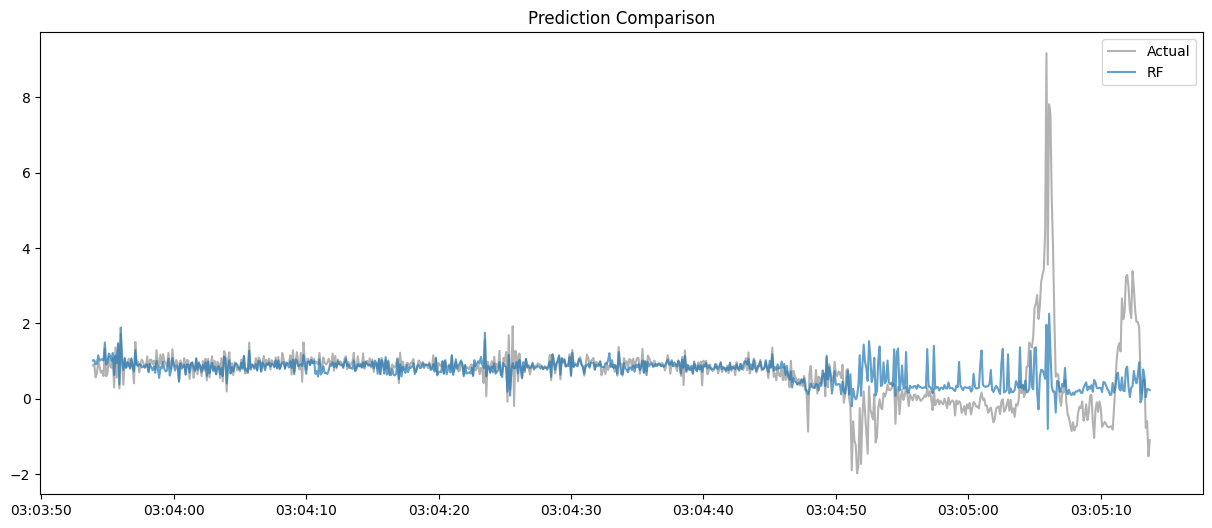

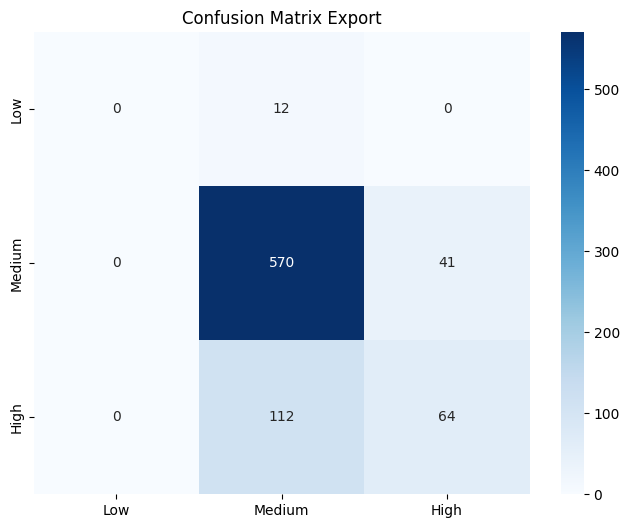

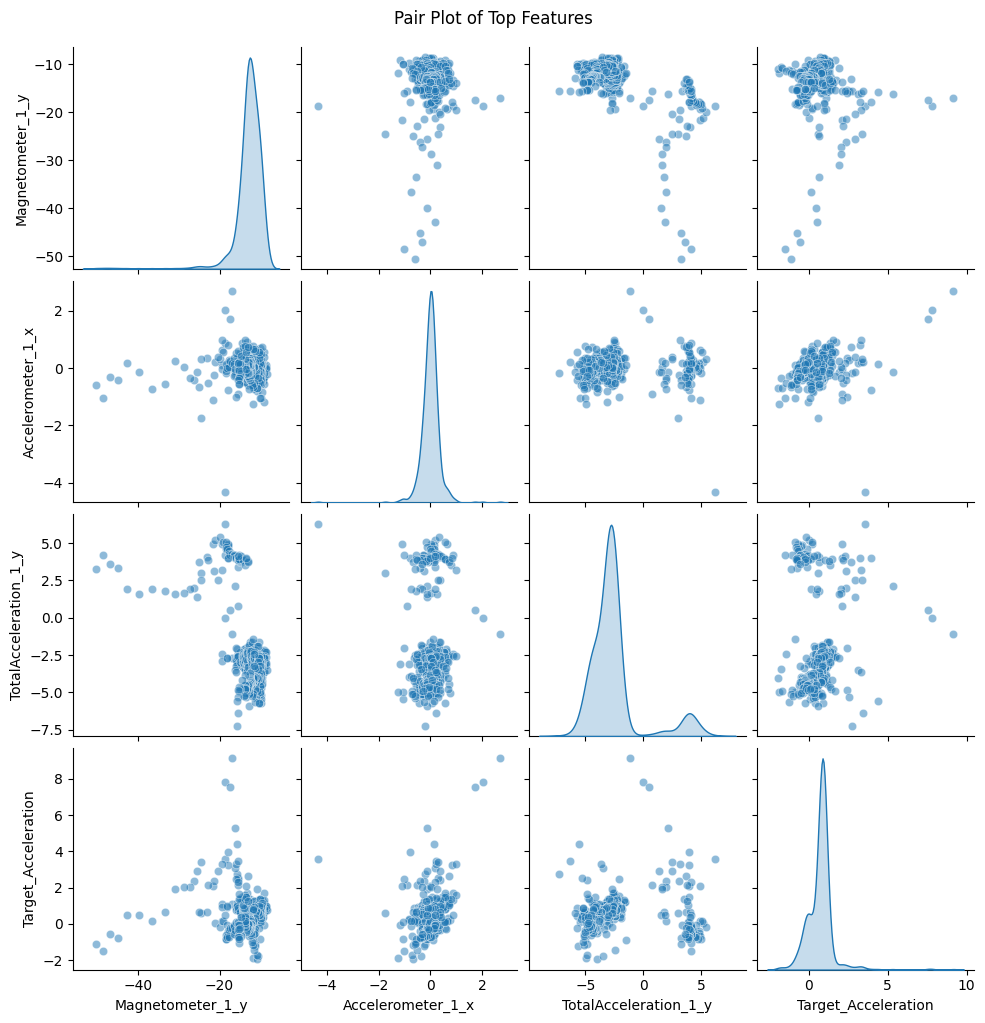

All tables and images saved successfully to the current folder.


In [55]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# ==========================================
# 1. DATA PREPROCESSING & MERGING
# ==========================================

def process_sensor_file(filepath):
    try:
        df = pd.read_csv(filepath)
        if 'time' not in df.columns and 'Time' in df.columns:
            df.rename(columns={'Time': 'time'}, inplace=True)
        sample_val = df['time'].iloc[0]
        unit = 'ns' if sample_val > 1e15 else ('us' if sample_val > 1e12 else 'ms')
        df['time'] = pd.to_datetime(df['time'], unit=unit)
        df = df.set_index('time')
        numeric_cols = df.select_dtypes(include=['number']).columns
        object_cols = df.select_dtypes(exclude=['number']).columns
        agg_dict = {col: 'mean' for col in numeric_cols}
        agg_dict.update({col: 'first' for col in object_cols})
        df_resampled = df.resample('100ms').agg(agg_dict).ffill()
        sensor_name = os.path.basename(filepath).replace('.csv', '')
        df_resampled.columns = [f'{sensor_name}_{col}' for col in df_resampled.columns]
        return df_resampled
    except Exception as e:
        print(f"Could not process {filepath}: {e}")
        return None

sensor_files = [
    '/content/TotalAcceleration_1.csv', '/content/Magnetometer_1.csv',
    '/content/Location_1.csv', '/content/Gyroscope_1.csv',
    '/content/Battery_1.csv', '/content/BatteryTemp_1.csv',
    '/content/Accelerometer_1.csv'
]

all_dfs = [process_sensor_file(f) for f in sensor_files if os.path.exists(f)]
all_dfs = [df for df in all_dfs if df is not None]

if all_dfs:
    merged_df = all_dfs[0]
    for next_df in all_dfs[1:]:
        merged_df = merged_df.join(next_df, how='outer')
    merged_df.to_csv('merged_sensor_data.csv')
    print(f"Success! Merged data shape: {merged_df.shape}")
else:
    print("No valid data was processed.")

# ==========================================
# 2. DATA ANALYSIS REPORT
# ==========================================

summary_df = pd.DataFrame({
    'Attribute': ['Format', 'Index', 'Rows', 'Columns', 'Time Range'],
    'Description': [
        'Pandas DataFrame (Time-series)', 'DatetimeIndex (100ms)',
        f"{merged_df.shape[0]:,}", str(merged_df.shape[1]),
        f"{merged_df.index.min()} to {merged_df.index.max()}"
    ]
})
summary_df.to_csv('data_structure_summary.csv', index=False)
display(summary_df)

# ==========================================
# 3. MACHINE LEARNING BENCHMARK
# ==========================================

data_ml = merged_df.dropna().select_dtypes(include=[np.number])
target_col = 'TotalAcceleration_1_x'
X = data_ml.drop(columns=[target_col])
y = data_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

window = 10
def create_sequences(data, target, window_size):
    X_s, y_s = [], []
    for i in range(len(data) - window_size):
        X_s.append(data[i:i+window_size])
        y_s.append(target.iloc[i+window_size])
    return np.array(X_s), np.array(y_s)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, window)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, window)

lstm_model = Sequential([
    Input(shape=(window, X_train_seq.shape[2])),
    LSTM(50, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
lstm_preds = lstm_model.predict(X_test_seq).flatten()

# ==========================================
# 4. EXPORT RESULTS & VISUALIZATIONS
# ==========================================

results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'R2 Score': [r2_score(y_test, rf_preds), r2_score(y_test, xgb_preds), r2_score(y_test_seq, lstm_preds)],
    'MSE': [mean_squared_error(y_test, rf_preds), mean_squared_error(y_test, xgb_preds), mean_squared_error(y_test_seq, lstm_preds)]
})
results_df.to_csv('model_benchmarks.csv', index=False)
display(results_df)

# Prediction Plot
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual', alpha=0.3, color='black')
plt.plot(y_test.index, rf_preds, label='RF', alpha=0.7)
plt.title('Prediction Comparison')
plt.legend()
plt.savefig('prediction_comparison.png', dpi=300)
plt.show()

# Confusion Matrix
def bin_acceleration(val):
    if val < -1.0: return 'Low'
    elif val < 1.0: return 'Medium'
    else: return 'High'
y_test_binned = [bin_acceleration(v) for v in y_test]
rf_preds_binned = [bin_acceleration(v) for v in rf_preds]
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test_binned, rf_preds_binned, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Export')
plt.savefig('confusion_matrix_rf.png', dpi=300)
plt.show()

# Feature Importance
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
feature_importance_df.to_csv('feature_importance.csv', index=False)

# Pair Plot
top_features = feature_importance_df['Feature'].head(3).tolist()
plot_df = X_test[top_features].copy()
plot_df['Target_Acceleration'] = y_test.values
g = sns.pairplot(plot_df, diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pair Plot of Top Features', y=1.02)
plt.savefig('pair_plot_top_features.png', dpi=300)
plt.show()

print("All tables and images saved successfully to the current folder.")